Architecture:

- **CNN encoder:** ResNet18 extracts image features.
- **Attention module:** learns which image regions matter at each word.
- **LSTM decoder:** generates the caption word by word.

Expected Google Drive structure:

```text
MyDrive/visual_storyteller/
├── data/
│   ├── captions.txt
│   └── Images/
│       ├── 1000268201_693b08cb0e.jpg
│       └── ...
└── models/
```

In [73]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from pathlib import Path
PROJECT_DIR = Path('/content/drive/MyDrive/visual_storyteller/visual_storyteller')
print('PROJECT_DIR exists:', PROJECT_DIR.exists())
for p in PROJECT_DIR.rglob('*'):
    print(p)

Mounted at /content/drive
PROJECT_DIR exists: False


In [74]:
from pathlib import Path

copy_dir = Path('/content/drive/MyDrive/visual_storyteller/Copy of visual_storyteller')
print('Exists:', copy_dir.exists())
print()
for p in copy_dir.rglob('*'):
    print(p)

Streaming output truncated to the last 5000 lines.
/content/drive/MyDrive/visual_storyteller/Copy of visual_storyteller/data/Images/3146232740_df3da0163b.jpg
/content/drive/MyDrive/visual_storyteller/Copy of visual_storyteller/data/Images/3132006797_04822b5866.jpg
/content/drive/MyDrive/visual_storyteller/Copy of visual_storyteller/data/Images/3126773489_7ae425af17.jpg
/content/drive/MyDrive/visual_storyteller/Copy of visual_storyteller/data/Images/3141613533_595723208d.jpg
/content/drive/MyDrive/visual_storyteller/Copy of visual_storyteller/data/Images/3145967019_1a83ebf712.jpg
/content/drive/MyDrive/visual_storyteller/Copy of visual_storyteller/data/Images/3151492269_28d8edaa68.jpg
/content/drive/MyDrive/visual_storyteller/Copy of visual_storyteller/data/Images/3136043366_b3f8607a0e.jpg
/content/drive/MyDrive/visual_storyteller/Copy of visual_storyteller/data/Images/3138746531_f6b816c126.jpg
/content/drive/MyDrive/visual_storyteller/Copy of visual_storyteller/data/Images/315436114_6d

In [75]:
!ls /content/drive/MyDrive/

 10000000_2451328781602346_5999669713049747456_n.mp4
'based on my dataset what would be the values of t....gsheet'
'Colab Notebooks'
'Copy of Untitled spreadsheet.gsheet'
'Copy of visual_storyteller'
'Employee shift schedule.gsheet'
'Getting started.pdf'
'Google AI Studio'
 homework.zip
'jpg2pdf (1).gdoc'
'jpg2pdf (1).pdf'
 lv_0_20240802194649.mp4
 prod_2025-09_484261_a2a48e64-6490-4845-8c9b-c60f71369574.html
'SWB2025000007387_copy (1).pdf'
 SWB2025000007387_copy.pdf
'Untitled spreadsheet (1).gsheet'
'Untitled spreadsheet.gsheet'
 visual_storyteller
 visual_storyteller_outputs
'ანიმაციური ვიდეო რგოლები.mp4'
'დაბადების მოწმობა1 (1).pdf'
'დაბადების მოწმობა1.pdf'
'დაბადების მოწმობა2.pdf'
'დავალება 8.rar'
'დავალება 9.zip'
'თამარ მამალაძე-დედა-მოწმობა.pdf'
'თამარ მამალაძის პირადობის მოწმობა.pdf'
'თამუნას მოპწმობა.jpg'
'თამუნას მოპწმობა.pdf'
'ლუკა მექოშვილი (1) (1).pdf'
'ლუკა მექოშვილი (1).pdf'
'ლუკა მექოშვილი (2) (1).jpg'
'ლუკა მექოშვილი (2) (1).pdf'
'ლუკა მექოშვილი (2).jpg'
'ლუკა მექოშვილი

In [76]:
# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('Google Drive mount skipped. This is normal if you are not running in Colab.')
    print(e)

from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/visual_storyteller/Copy of visual_storyteller')
DATA_DIR = PROJECT_DIR / 'data'
CAPTIONS_PATH = DATA_DIR / 'captions.txt'
IMAGE_DIR = DATA_DIR / 'Images'

MODELS_DIR = PROJECT_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = MODELS_DIR / 'caption_model_best.pth'
FINAL_MODEL_PATH = MODELS_DIR / 'caption_model_final.pth'

print('Captions exist:', CAPTIONS_PATH.exists())
print('Images exist:', IMAGE_DIR.exists())
print('JPG count:', len(list(IMAGE_DIR.glob('*.jpg'))))

# Outputs (checkpoints, split CSVs) go to a folder YOU own, since the shared
# data folder is read-only and writing there causes PermissionError.
MODELS_DIR = Path('/content/drive/MyDrive/visual_storyteller_outputs')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Training mode
FAST_DEV_RUN = False       # True = small subset for testing; False = full dataset
MAX_DEV_IMAGES = 500       # used only when FAST_DEV_RUN=True

# Data / model hyperparameters
SEED = 42
IMAGE_SIZE = 224
MAX_CAPTION_LEN = 30       # includes <start> and <end>
MIN_WORD_FREQ = 2
BATCH_SIZE = 64
NUM_WORKERS = 2
EPOCHS = 8 if not FAST_DEV_RUN else 2
LEARNING_RATE = 1e-3
CLIP_GRAD_NORM = 5.0
USE_AMP = True             # mixed precision on GPU

# Optimization schedule
LR_PATIENCE = 2
EARLY_STOP_PATIENCE = 3
ALPHA_C = 1.0

# Model architecture
ENCODED_IMAGE_SIZE = 7
ATTENTION_DIM = 256
EMBED_DIM = 256
DECODER_DIM = 512
DROPOUT = 0.5
USE_PRETRAINED_ENCODER = True
FINE_TUNE_ENCODER = False
GENERATION_MAX_LEN = 25
BEAM_SIZE = 3

CHECKPOINT_PATH = MODELS_DIR / 'caption_model_best.pth'
FINAL_MODEL_PATH = MODELS_DIR / 'caption_model_final.pth'

print('Project folder:', PROJECT_DIR)
print('Captions file:', CAPTIONS_PATH, '| exists:', CAPTIONS_PATH.exists())
print('Image folder:', IMAGE_DIR, '| exists:', IMAGE_DIR.exists())
if IMAGE_DIR.exists():
    print('JPG count:', len(list(IMAGE_DIR.glob('*.jpg'))))
print('Model output (yours):', MODELS_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Captions exist: True
Images exist: True
JPG count: 8091
Project folder: /content/drive/MyDrive/visual_storyteller/Copy of visual_storyteller
Captions file: /content/drive/MyDrive/visual_storyteller/Copy of visual_storyteller/data/captions.txt | exists: True
Image folder: /content/drive/MyDrive/visual_storyteller/Copy of visual_storyteller/data/Images | exists: True
JPG count: 8091
Model output (yours): /content/drive/MyDrive/visual_storyteller_outputs


## 2. Imports and reproducibility

In [77]:
import os
import re
import time
import json
import math
import random
import zipfile
import functools
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision import models, transforms

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


## 3. Prepare dataset from Google Drive


In [78]:
def find_image_folder(data_dir: Path, preferred: Path):
    candidates = [
        preferred,
        data_dir / 'images',
        data_dir / 'Images',
        data_dir / 'Flickr8k_Dataset',
        data_dir / 'flickr8k' / 'Images',
        data_dir / 'caption_data' / 'Images',
        data_dir / 'caption_data' / 'images',
    ]
    for c in candidates:
        if c.exists() and any(c.glob('*.jpg')):
            return c

    jpg_files = list(data_dir.rglob('*.jpg'))
    if len(jpg_files) > 0:
        return jpg_files[0].parent

    raise FileNotFoundError(
        f'Could not find image files under {data_dir}. '
        'Put .jpg files in data/Images or put caption_data.zip in data/.'
    )

IMAGE_DIR = find_image_folder(DATA_DIR, IMAGE_DIR)
print('Using image folder:', IMAGE_DIR)
print('Number of jpg files found:', len(list(IMAGE_DIR.glob('*.jpg'))))

if not CAPTIONS_PATH.exists():
    # Sometimes captions.txt may be inside the extracted zip.
    found = list(DATA_DIR.rglob('captions.txt'))
    if found:
        CAPTIONS_PATH = found[0]
        print('Found captions file at:', CAPTIONS_PATH)
    else:
        raise FileNotFoundError(f'Could not find captions.txt under {DATA_DIR}')

Using image folder: /content/drive/MyDrive/visual_storyteller/Copy of visual_storyteller/data/Images
Number of jpg files found: 8091


In [79]:
PROJECT_DIR = Path('/content/drive/MyDrive/Copy of visual_storyteller')
for p in PROJECT_DIR.rglob('*'):
    print(p)

/content/drive/MyDrive/Copy of visual_storyteller/visual_storyteller
/content/drive/MyDrive/Copy of visual_storyteller/visual_storyteller/models


In [80]:
copy_root = Path('/content/drive/MyDrive/Copy of visual_storyteller')
for p in copy_root.rglob('*'):
    print(p)

/content/drive/MyDrive/Copy of visual_storyteller/visual_storyteller
/content/drive/MyDrive/Copy of visual_storyteller/visual_storyteller/models


In [81]:
print('DATA_DIR:', DATA_DIR)
print()
for p in PROJECT_DIR.rglob('*'):
    print(p)

DATA_DIR: /content/drive/MyDrive/visual_storyteller/Copy of visual_storyteller/data

/content/drive/MyDrive/Copy of visual_storyteller/visual_storyteller
/content/drive/MyDrive/Copy of visual_storyteller/visual_storyteller/models


In [82]:
nested = PROJECT_DIR / 'visual_storyteller'
for p in nested.rglob('*'):
    print(p)

/content/drive/MyDrive/Copy of visual_storyteller/visual_storyteller/models


In [83]:
print('DATA_DIR:', DATA_DIR)
print('Exists:', DATA_DIR.exists())
print()
for p in PROJECT_DIR.rglob('*'):
    print(p)

DATA_DIR: /content/drive/MyDrive/visual_storyteller/Copy of visual_storyteller/data
Exists: True

/content/drive/MyDrive/Copy of visual_storyteller/visual_storyteller
/content/drive/MyDrive/Copy of visual_storyteller/visual_storyteller/models


In [84]:
import subprocess
print(subprocess.run(['find', '/content/drive/MyDrive', '-iname', '*.jpg'], capture_output=True, text=True).stdout[:3000])

/content/drive/MyDrive/ლუკა მექოშვილი (5).JPG
/content/drive/MyDrive/ლუკა მექოშვილი (2) (1).jpg
/content/drive/MyDrive/ლუკა მექოშვილი (2).jpg
/content/drive/MyDrive/ლუკა მექოშვილი (3).jpg
/content/drive/MyDrive/სკოლის ცნობა.jpg
/content/drive/MyDrive/თამუნას მოპწმობა.jpg



## 4. Load captions

The captions file should contain two columns: `image` and `caption`.

In [85]:
def load_captions(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if not {'image', 'caption'}.issubset(df.columns):
        raise ValueError('captions.txt must have columns: image, caption')
    df = df[['image', 'caption']].copy()
    df['image'] = df['image'].astype(str).str.strip()
    df['caption'] = df['caption'].astype(str).str.strip()
    df = df[df['caption'].str.len() > 0].reset_index(drop=True)
    return df

captions_df = load_captions(CAPTIONS_PATH)
print('Total caption rows:', len(captions_df))
print('Unique images in captions:', captions_df['image'].nunique())
display(captions_df.head())

# Keep rows whose image file exists.
existing_mask = captions_df['image'].apply(lambda name: (IMAGE_DIR / name).exists())
missing_count = int((~existing_mask).sum())
if missing_count > 0:
    print('Warning: caption rows with missing images:', missing_count)

captions_df = captions_df[existing_mask].reset_index(drop=True)
print('Caption rows with existing images:', len(captions_df))
print('Unique existing images:', captions_df['image'].nunique())

if captions_df.empty:
    raise RuntimeError('No caption rows match local image files. Check IMAGE_DIR and captions.txt filenames.')

if FAST_DEV_RUN:
    unique = captions_df['image'].drop_duplicates().sample(
        n=min(MAX_DEV_IMAGES, captions_df['image'].nunique()), random_state=SEED
    )
    captions_df = captions_df[captions_df['image'].isin(set(unique))].reset_index(drop=True)
    print('FAST_DEV_RUN rows:', len(captions_df))
    print('FAST_DEV_RUN images:', captions_df['image'].nunique())

Total caption rows: 40455
Unique images in captions: 8091


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


Caption rows with existing images: 40455
Unique existing images: 8091


## 5. Split by image

Each image has multiple captions. We split by **image**, not by row, so captions from the same image do not appear in both train and test.

In [86]:
def split_by_image(df: pd.DataFrame, val_ratio=0.10, test_ratio=0.10, seed=42):
    rng = np.random.default_rng(seed)
    images = df['image'].drop_duplicates().to_numpy()
    rng.shuffle(images)

    n_total = len(images)
    n_test = max(1, int(n_total * test_ratio))
    n_val = max(1, int(n_total * val_ratio))

    test_images = set(images[:n_test])
    val_images = set(images[n_test:n_test + n_val])
    train_images = set(images[n_test + n_val:])

    train_df = df[df['image'].isin(train_images)].reset_index(drop=True)
    val_df = df[df['image'].isin(val_images)].reset_index(drop=True)
    test_df = df[df['image'].isin(test_images)].reset_index(drop=True)
    return train_df, val_df, test_df

train_df, val_df, test_df = split_by_image(captions_df, seed=SEED)

print('Train rows/images:', len(train_df), '/', train_df['image'].nunique())
print('Val rows/images:', len(val_df), '/', val_df['image'].nunique())
print('Test rows/images:', len(test_df), '/', test_df['image'].nunique())

# Save splits so inference.ipynb can reuse unseen test images.
train_df.to_csv(MODELS_DIR / 'train_split.csv', index=False)
val_df.to_csv(MODELS_DIR / 'val_split.csv', index=False)
test_df.to_csv(MODELS_DIR / 'test_split.csv', index=False)

Train rows/images: 32365 / 6473
Val rows/images: 4045 / 809
Test rows/images: 4045 / 809


## 6. Build vocabulary

We use a simple regex tokenizer and four special tokens:

- `<pad>` for batch padding
- `<start>` to start generation
- `<end>` to stop generation
- `<unk>` for rare/unknown words

In [87]:
TOKEN_PATTERN = re.compile(r"[a-zA-Z]+|[0-9]+")


def tokenize(text: str):
    return TOKEN_PATTERN.findall(str(text).lower())


class Vocabulary:
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.specials = ['<pad>', '<start>', '<end>', '<unk>']
        self.word2idx = {token: i for i, token in enumerate(self.specials)}
        self.idx2word = {i: token for token, i in self.word2idx.items()}

    @property
    def pad_idx(self): return self.word2idx['<pad>']
    @property
    def start_idx(self): return self.word2idx['<start>']
    @property
    def end_idx(self): return self.word2idx['<end>']
    @property
    def unk_idx(self): return self.word2idx['<unk>']

    def __len__(self):
        return len(self.word2idx)

    def build(self, captions):
        counter = Counter()
        for caption in captions:
            counter.update(tokenize(caption))

        for word, freq in sorted(counter.items()):
            if freq >= self.min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def encode(self, caption: str, max_len: int):
        tokens = tokenize(caption)
        token_ids = [self.word2idx.get(t, self.unk_idx) for t in tokens]
        # Reserve space for <start> and <end>.
        token_ids = token_ids[:max_len - 2]
        return [self.start_idx] + token_ids + [self.end_idx]

    def decode_ids(self, ids):
        words = []
        for idx in ids:
            idx = int(idx)
            word = self.idx2word.get(idx, '<unk>')
            if word == '<end>':
                break
            if word not in {'<pad>', '<start>', '<end>'}:
                words.append(word)
        return ' '.join(words)

    def to_dict(self):
        return {
            'min_freq': self.min_freq,
            'word2idx': self.word2idx,
            'idx2word': {str(k): v for k, v in self.idx2word.items()},
        }

    @classmethod
    def from_dict(cls, data):
        vocab = cls(min_freq=data.get('min_freq', 2))
        vocab.word2idx = {str(k): int(v) for k, v in data['word2idx'].items()}
        vocab.idx2word = {int(k): str(v) for k, v in data['idx2word'].items()}
        return vocab

vocab = Vocabulary(min_freq=MIN_WORD_FREQ)
vocab.build(train_df['caption'])

print('Vocabulary size:', len(vocab))
print('pad/start/end/unk:', vocab.pad_idx, vocab.start_idx, vocab.end_idx, vocab.unk_idx)
example = train_df.iloc[0]['caption']
print('Example caption:', example)
print('Encoded:', vocab.encode(example, MAX_CAPTION_LEN))
print('Decoded:', vocab.decode_ids(vocab.encode(example, MAX_CAPTION_LEN)))

Vocabulary size: 4640
pad/start/end/unk: 0 1 2 3
Example caption: A child in a pink dress is climbing up a set of stairs in an entry way .
Encoded: [1, 21, 758, 2004, 21, 2896, 1214, 2053, 806, 4364, 21, 3450, 2637, 3837, 2004, 108, 3, 4485, 2]
Decoded: a child in a pink dress is climbing up a set of stairs in an <unk> way


## 7. Dataset and DataLoader

In [88]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class CaptionDataset(Dataset):
    def __init__(self, df, image_dir, vocab, transform=None, max_len=30):
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.vocab = vocab
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_name = row['image']
        caption_text = row['caption']
        image_path = self.image_dir / image_name

        image = Image.open(image_path).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)

        caption_ids = torch.tensor(self.vocab.encode(caption_text, self.max_len), dtype=torch.long)
        return image, caption_ids, image_name, caption_text


def collate_fn(batch, pad_idx):
    images, captions, image_names, raw_captions = zip(*batch)
    images = torch.stack(images, dim=0)
    lengths = torch.tensor([len(c) for c in captions], dtype=torch.long)
    captions = pad_sequence(captions, batch_first=True, padding_value=pad_idx)
    return images, captions, lengths, list(image_names), list(raw_captions)


# Bind pad_idx once so DataLoader workers don't depend on the `vocab` global.
collate = functools.partial(collate_fn, pad_idx=vocab.pad_idx)

train_dataset = CaptionDataset(train_df, IMAGE_DIR, vocab, train_transform, MAX_CAPTION_LEN)
val_dataset = CaptionDataset(val_df, IMAGE_DIR, vocab, val_transform, MAX_CAPTION_LEN)
test_dataset = CaptionDataset(test_df, IMAGE_DIR, vocab, val_transform, MAX_CAPTION_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate,
    pin_memory=(DEVICE.type == 'cuda'),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate,
    pin_memory=(DEVICE.type == 'cuda'),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate,
    pin_memory=(DEVICE.type == 'cuda'),
)

images, captions, lengths, names, texts = next(iter(train_loader))
print('Image batch:', images.shape)
print('Caption batch:', captions.shape)
print('Example image:', names[0])
print('Example caption:', texts[0])


Image batch: torch.Size([64, 3, 224, 224])
Caption batch: torch.Size([64, 27])
Example image: 1775029934_e1e96038a8.jpg
Example caption: A wild animal races across an uncut field with a minimal amount of trees .


## 8. Model definition: ResNet encoder + attention LSTM decoder

The encoder creates a grid of visual features. The decoder attends to this grid and predicts the next word.

In [89]:
class EncoderCNN(nn.Module):
    def __init__(self, encoded_image_size=7, pretrained=True, fine_tune=False):
        super().__init__()
        self.enc_image_size = encoded_image_size

        try:
            weights = models.ResNet18_Weights.DEFAULT if pretrained else None
            resnet = models.resnet18(weights=weights)
        except Exception as e:
            print('Could not load pretrained ResNet18 weights. Using random initialization.')
            print(e)
            resnet = models.resnet18(weights=None)

        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))
        self.fine_tune(fine_tune)

    def forward(self, images):
        out = self.resnet(images)                # [B, 512, H, W]
        out = self.adaptive_pool(out)            # [B, 512, 7, 7]
        out = out.permute(0, 2, 3, 1)            # [B, 7, 7, 512]
        return out

    def fine_tune(self, fine_tune=True):
        for p in self.resnet.parameters():
            p.requires_grad = False
        # Fine-tune only later ResNet blocks if requested.
        if fine_tune:
            for child in list(self.resnet.children())[5:]:
                for p in child.parameters():
                    p.requires_grad = True


class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        # encoder_out: [B, num_pixels, encoder_dim]
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden)
        att = self.full_att(self.relu(att1 + att2.unsqueeze(1))).squeeze(2)
        alpha = self.softmax(att)
        attention_weighted_encoding = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return attention_weighted_encoding, alpha


class DecoderWithAttention(nn.Module):
    def __init__(self, attention_dim, embed_dim, decoder_dim, vocab_size,
                 encoder_dim=512, dropout=0.5):
        super().__init__()
        self.encoder_dim = encoder_dim
        self.attention_dim = attention_dim
        self.embed_dim = embed_dim
        self.decoder_dim = decoder_dim
        self.vocab_size = vocab_size

        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.decode_step = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)
        self.sigmoid = nn.Sigmoid()
        self.fc = nn.Linear(decoder_dim, vocab_size)
        self.init_weights()

    def init_weights(self):
        self.embedding.weight.data.uniform_(-0.1, 0.1)
        self.fc.bias.data.fill_(0)
        self.fc.weight.data.uniform_(-0.1, 0.1)

    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)
        c = self.init_c(mean_encoder_out)
        return h, c

    def forward(self, encoder_out, captions):
        batch_size = encoder_out.size(0)
        encoder_dim = encoder_out.size(-1)
        vocab_size = self.vocab_size

        # Flatten image grid.
        encoder_out = encoder_out.view(batch_size, -1, encoder_dim)
        num_pixels = encoder_out.size(1)

        # Teacher forcing: input is everything except last token.
        embeddings = self.embedding(captions[:, :-1])
        decode_len = captions.size(1) - 1

        h, c = self.init_hidden_state(encoder_out)
        predictions = torch.zeros(batch_size, decode_len, vocab_size, device=encoder_out.device)
        alphas = torch.zeros(batch_size, decode_len, num_pixels, device=encoder_out.device)

        for t in range(decode_len):
            attention_weighted_encoding, alpha = self.attention(encoder_out, h)
            gate = self.sigmoid(self.f_beta(h))
            attention_weighted_encoding = gate * attention_weighted_encoding
            h, c = self.decode_step(
                torch.cat([embeddings[:, t, :], attention_weighted_encoding], dim=1),
                (h, c),
            )
            preds = self.fc(self.dropout(h))
            predictions[:, t, :] = preds
            alphas[:, t, :] = alpha

        return predictions, alphas


class ImageCaptioningModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.encoder = EncoderCNN(
            encoded_image_size=ENCODED_IMAGE_SIZE,
            pretrained=USE_PRETRAINED_ENCODER,
            fine_tune=FINE_TUNE_ENCODER,
        )
        self.decoder = DecoderWithAttention(
            attention_dim=ATTENTION_DIM,
            embed_dim=EMBED_DIM,
            decoder_dim=DECODER_DIM,
            vocab_size=vocab_size,
            encoder_dim=512,
            dropout=DROPOUT,
        )

    def forward(self, images, captions):
        encoder_out = self.encoder(images)
        predictions, alphas = self.decoder(encoder_out, captions)
        return predictions, alphas

model = ImageCaptioningModel(vocab_size=len(vocab)).to(DEVICE)
print(model.__class__.__name__)
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]


ImageCaptioningModel
Trainable parameters: 7244577


## 9. Training and validation functions

In [90]:
criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=LR_PATIENCE)
scaler = torch.amp.GradScaler('cuda', enabled=(USE_AMP and DEVICE.type == 'cuda'))


def batch_loss(outputs, captions, alphas=None):
    # outputs predict captions[:, 1:] because captions[:, 0] is <start>.
    targets = captions[:, 1:]
    loss = criterion(outputs.reshape(-1, outputs.size(-1)), targets.reshape(-1))
    if alphas is not None:
        # Doubly-stochastic attention regularization (Show, Attend and Tell):
        # pushes the total attention paid to each image region (summed over the
        # caption) toward 1, so the model learns to look at the whole image
        # instead of fixating on a few pixels.
        attention_reg = ((1. - alphas.sum(dim=1)) ** 2).mean()
        loss = loss + ALPHA_C * attention_reg
    return loss


def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss = 0.0
    total_batches = 0

    progress = tqdm(loader, desc='train', leave=False)
    for images, captions, lengths, names, raw_caps in progress:
        images = images.to(DEVICE, non_blocking=True)
        captions = captions.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=(USE_AMP and DEVICE.type == 'cuda')):
            outputs, alphas = model(images, captions)
            loss = batch_loss(outputs, captions, alphas)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD_NORM)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_batches += 1
        progress.set_postfix(loss=f'{loss.item():.4f}')

    return total_loss / max(1, total_batches)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_batches = 0

    for images, captions, lengths, names, raw_caps in tqdm(loader, desc='val', leave=False):
        images = images.to(DEVICE, non_blocking=True)
        captions = captions.to(DEVICE, non_blocking=True)
        outputs, alphas = model(images, captions)
        loss = batch_loss(outputs, captions, alphas)
        total_loss += loss.item()
        total_batches += 1

    return total_loss / max(1, total_batches)


def make_checkpoint(model, vocab, history, epoch, best_val_loss):
    config = {
        'image_size': IMAGE_SIZE,
        'max_caption_len': MAX_CAPTION_LEN,
        'min_word_freq': MIN_WORD_FREQ,
        'encoded_image_size': ENCODED_IMAGE_SIZE,
        'attention_dim': ATTENTION_DIM,
        'embed_dim': EMBED_DIM,
        'decoder_dim': DECODER_DIM,
        'dropout': DROPOUT,
        'generation_max_len': GENERATION_MAX_LEN,
        'beam_size': BEAM_SIZE,
    }
    return {
        'epoch': epoch,
        'best_val_loss': best_val_loss,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'vocab': vocab.to_dict(),
        'config': config,
        'history': history,
    }


## 10. Train the model

The best checkpoint is saved to Google Drive as `models/caption_model_best.pth`.

In [91]:
history = []
best_val_loss = float('inf')
epochs_no_improve = 0
final_epoch = 0

start_time = time.time()
for epoch in range(1, EPOCHS + 1):
    print(f'\nEpoch {epoch}/{EPOCHS}')
    train_loss = train_one_epoch(model, train_loader, optimizer, scaler)
    val_loss = evaluate(model, val_loader)
    scheduler.step(val_loss)
    final_epoch = epoch

    current_lr = optimizer.param_groups[0]['lr']
    row = {'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 'lr': current_lr}
    history.append(row)

    print(f'Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | LR: {current_lr:.2e}')

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        epochs_no_improve = 0
        checkpoint = make_checkpoint(model, vocab, history, epoch, best_val_loss)
        torch.save(checkpoint, CHECKPOINT_PATH)
        print('Saved new best checkpoint:', CHECKPOINT_PATH)
    else:
        epochs_no_improve += 1
        print(f'No improvement for {epochs_no_improve} epoch(s).')
        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f'Early stopping triggered after epoch {epoch}.')
            break

# Save final model too.
final_checkpoint = make_checkpoint(model, vocab, history, final_epoch, best_val_loss)
torch.save(final_checkpoint, FINAL_MODEL_PATH)

elapsed = (time.time() - start_time) / 60
print(f'Finished training in {elapsed:.1f} minutes')
print('Best checkpoint:', CHECKPOINT_PATH)
print('Final checkpoint:', FINAL_MODEL_PATH)



Epoch 1/8


train:   0%|          | 0/506 [00:00<?, ?it/s]

val:   0%|          | 0/64 [00:00<?, ?it/s]

Train loss: 4.3395 | Val loss: 3.6112 | LR: 1.00e-03
Saved new best checkpoint: /content/drive/MyDrive/visual_storyteller_outputs/caption_model_best.pth

Epoch 2/8


train:   0%|          | 0/506 [00:00<?, ?it/s]

...

Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7dc0690fe700>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7dc0690fe700>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
Exception ignored in: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        <function _MultiProcessingDataLoaderIter.__del__ at 0x7dc0690fe700>if w.is_alive():
 if w.is_alive(): 
  Traceback (most recent call last):

   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1

Train loss: 2.7753 | Val loss: 3.0781 | LR: 1.00e-03
Saved new best checkpoint: /content/drive/MyDrive/visual_storyteller_outputs/caption_model_best.pth

Epoch 8/8


train:   0%|          | 0/506 [00:00<?, ?it/s]

val:   0%|          | 0/64 [00:00<?, ?it/s]

Train loss: 2.6912 | Val loss: 3.0750 | LR: 1.00e-03
Saved new best checkpoint: /content/drive/MyDrive/visual_storyteller_outputs/caption_model_best.pth
Finished training in 49.7 minutes
Best checkpoint: /content/drive/MyDrive/visual_storyteller_outputs/caption_model_best.pth
Final checkpoint: /content/drive/MyDrive/visual_storyteller_outputs/caption_model_final.pth


## 11. Plot training progress

,epoch,train_loss,val_loss,lr
0,1,4.339549,3.611200,0.001
1,2,3.549876,3.347224,0.001
2,3,3.291105,3.229462,0.001
3,4,3.118663,3.154800,0.001
4,5,2.980441,3.109648,0.001
5,6,2.870843,3.084347,0.001
6,7,2.775326,3.078113,0.001
7,8,2.691161,3.075049,0.001


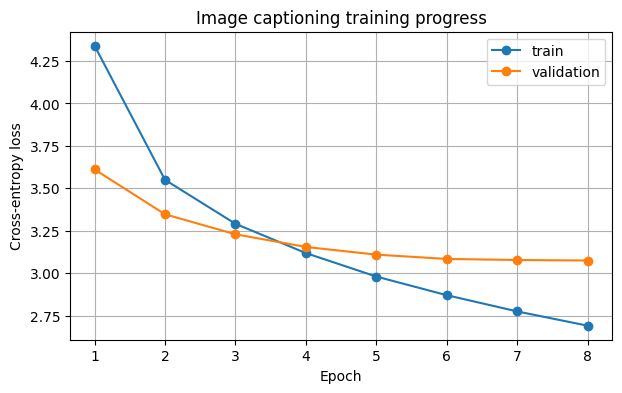

In [92]:
history_df = pd.DataFrame(history)
display(history_df)

plt.figure(figsize=(7, 4))
plt.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train')
plt.plot(history_df['epoch'], history_df['val_loss'], marker='o', label='validation')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('Image captioning training progress')
plt.legend()
plt.grid(True)
plt.show()

## 12. Caption generation helper


In [93]:
@torch.no_grad()
def greedy_generate_caption(image_path, model, vocab, transform, device, max_len=25):
    model.eval()
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    encoder_out = model.encoder(image_tensor)
    batch_size = encoder_out.size(0)
    encoder_dim = encoder_out.size(-1)
    encoder_out = encoder_out.view(batch_size, -1, encoder_dim)

    h, c = model.decoder.init_hidden_state(encoder_out)
    word = torch.tensor([vocab.start_idx], dtype=torch.long, device=device)

    generated_ids = []
    for _ in range(max_len):
        embeddings = model.decoder.embedding(word)
        attention_weighted_encoding, alpha = model.decoder.attention(encoder_out, h)
        gate = model.decoder.sigmoid(model.decoder.f_beta(h))
        attention_weighted_encoding = gate * attention_weighted_encoding
        h, c = model.decoder.decode_step(torch.cat([embeddings, attention_weighted_encoding], dim=1), (h, c))
        scores = model.decoder.fc(h)
        next_id = int(scores.argmax(dim=1).item())

        if next_id == vocab.end_idx:
            break
        generated_ids.append(next_id)
        word = torch.tensor([next_id], dtype=torch.long, device=device)

    return vocab.decode_ids(generated_ids)


@torch.no_grad()
def beam_search_generate_caption(image_path, model, vocab, transform, device, beam_size=3, max_len=25):
    """Beam search decoding — usually gives noticeably better captions than
    greedy decoding because it doesn't commit to the single best word at
    every step, only the best full sequence at the end."""
    model.eval()
    vocab_size = len(vocab)
    k = beam_size

    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    encoder_out = model.encoder(image_tensor)
    encoder_dim = encoder_out.size(-1)
    encoder_out = encoder_out.view(1, -1, encoder_dim)
    num_pixels = encoder_out.size(1)
    encoder_out = encoder_out.expand(k, num_pixels, encoder_dim)

    k_prev_words = torch.full((k, 1), vocab.start_idx, dtype=torch.long, device=device)
    seqs = k_prev_words
    top_k_scores = torch.zeros(k, 1, device=device)

    complete_seqs = []
    complete_seqs_scores = []

    h, c = model.decoder.init_hidden_state(encoder_out)

    step = 1
    while True:
        embeddings = model.decoder.embedding(k_prev_words).squeeze(1)
        awe, _ = model.decoder.attention(encoder_out, h)
        gate = model.decoder.sigmoid(model.decoder.f_beta(h))
        awe = gate * awe
        h, c = model.decoder.decode_step(torch.cat([embeddings, awe], dim=1), (h, c))

        scores = torch.log_softmax(model.decoder.fc(h), dim=1)
        scores = top_k_scores.expand_as(scores) + scores

        if step == 1:
            # All k beams are identical on the first step, so only expand beam 0.
            top_k_scores, top_k_words = scores[0].topk(k, 0, True, True)
        else:
            top_k_scores, top_k_words = scores.view(-1).topk(k, 0, True, True)

        prev_word_inds = torch.div(top_k_words, vocab_size, rounding_mode='floor')
        next_word_inds = top_k_words % vocab_size

        seqs = torch.cat([seqs[prev_word_inds], next_word_inds.unsqueeze(1)], dim=1)

        incomplete_inds = [i for i, w in enumerate(next_word_inds) if w != vocab.end_idx]
        complete_inds = list(set(range(len(next_word_inds))) - set(incomplete_inds))

        if complete_inds:
            complete_seqs.extend(seqs[complete_inds].tolist())
            complete_seqs_scores.extend(top_k_scores[complete_inds].tolist())
        k -= len(complete_inds)

        if k == 0 or step >= max_len:
            break

        seqs = seqs[incomplete_inds]
        h = h[prev_word_inds[incomplete_inds]]
        c = c[prev_word_inds[incomplete_inds]]
        encoder_out = encoder_out[prev_word_inds[incomplete_inds]]
        top_k_scores = top_k_scores[incomplete_inds].unsqueeze(1)
        k_prev_words = next_word_inds[incomplete_inds].unsqueeze(1)
        step += 1

    if complete_seqs_scores:
        best_idx = int(max(range(len(complete_seqs_scores)), key=lambda i: complete_seqs_scores[i]))
        best_seq = complete_seqs[best_idx]
    else:
        # No beam reached <end> in time; fall back to the best unfinished one.
        best_idx = int(top_k_scores.squeeze(1).argmax().item())
        best_seq = seqs[best_idx].tolist()

    generated_ids = [w for w in best_seq if w not in (vocab.start_idx, vocab.end_idx)]
    return vocab.decode_ids(generated_ids)


## 13. Quick validation examples


Loaded best checkpoint from: /content/drive/MyDrive/visual_storyteller_outputs/caption_model_best.pth


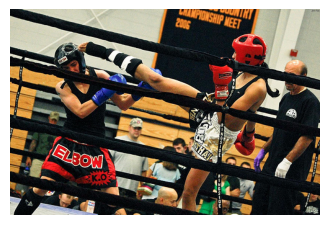

Image: 3679341667_936769fd0c.jpg
Predicted (beam search): a man in a black shirt and red shirt is riding a bicycle
References:
- two fighters kick boxing
- Two people kick boxing , with others spectating .
- Two woman spar in a kickboxing match .
- two women are kick boxing .
- Woman kicking head of another kick boxer

--------------------------------------------------------------------------------



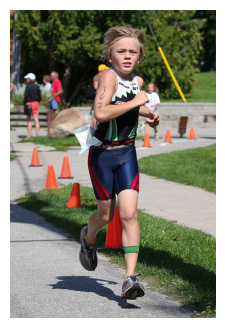

Image: 2768662025_44001fe5d1.jpg
Predicted (beam search): a young girl in a pink shirt is holding a pink umbrella
References:
- a boy runs along the street .
- A child running on the sidewalk .
- a young boy running in a street race
- A young boy runs in a race .
- Blond child running in a race .

--------------------------------------------------------------------------------



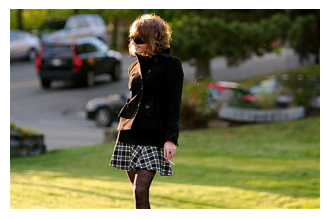

Image: 2561341745_2d77d3ff7d.jpg
Predicted (beam search): a young girl in a black dress is walking down a path
References:
- A thin girl in black smokes a cigarette .
- A woman dressed in black and white smokes a cigarette in a grassy area .
- A woman wearing a plaid skirt stands holding a cigarette .
- The woman in the black coat is standing with a cigarette in her hand .
- Women wearing black standing and smoking .

--------------------------------------------------------------------------------



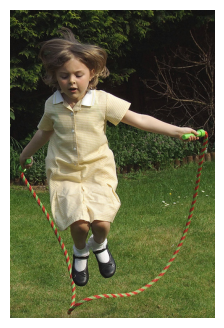

Image: 2908859957_e96c33c1e0.jpg
Predicted (beam search): a young girl plays with a hula hoop
References:
- A girl in a yellow dress jump ropes .
- A girl skips rope .
- A girl wearing yellow jumps over a red and green rope .
- A little girl in a yellow dress jumping rope .
- The little girl in the yellow dress is jumping over a red and green rope .

--------------------------------------------------------------------------------



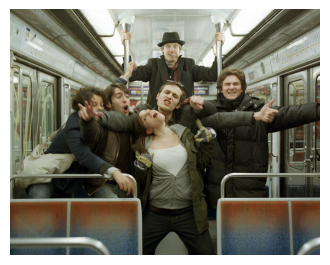

Image: 3402638444_dab914a3de.jpg
Predicted (beam search): a group of people are sitting at a table
References:
- Several young adults posing dramatically on a subway car .
- Six people pose together for a picture on the subway .
- Six young people are posing for a photograph on a subway train .
- Six young people posing for the camera inside of a train .
- Six young people cutting up on a subway .

--------------------------------------------------------------------------------



In [94]:
# Load the best checkpoint before generating examples.
if CHECKPOINT_PATH.exists():
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    print('Loaded best checkpoint from:', CHECKPOINT_PATH)

sample_images = test_df['image'].drop_duplicates().sample(
    n=min(5, test_df['image'].nunique()), random_state=SEED
).tolist()

for image_name in sample_images:
    image_path = IMAGE_DIR / image_name
    pred = beam_search_generate_caption(
        image_path, model, vocab, val_transform, DEVICE, BEAM_SIZE, GENERATION_MAX_LEN
    )
    refs = test_df[test_df['image'] == image_name]['caption'].tolist()[:5]

    img = Image.open(image_path).convert('RGB')
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    print('Image:', image_name)
    print('Predicted (beam search):', pred)
    print('References:')
    for r in refs:
        print('-', r)
    print('\n' + '-' * 80 + '\n')


## 14. Quantitative evaluation (BLEU)


In [95]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction


@torch.no_grad()
def evaluate_bleu(df, image_dir, model, vocab, transform, device,
                   beam_size=3, max_len=25, max_images=200, seed=42):
    """Corpus-level BLEU-1..4 against all reference captions per image.
    Loss alone doesn't tell us caption quality, so this gives an actual
    text-similarity metric on held-out images."""
    model.eval()
    unique_images = df['image'].drop_duplicates()
    if max_images is not None and len(unique_images) > max_images:
        unique_images = unique_images.sample(n=max_images, random_state=seed)

    references, hypotheses = [], []
    smoothing = SmoothingFunction().method4

    for image_name in tqdm(unique_images.tolist(), desc='BLEU eval'):
        image_path = image_dir / image_name
        pred = beam_search_generate_caption(image_path, model, vocab, transform, device, beam_size, max_len)
        refs = df[df['image'] == image_name]['caption'].tolist()

        hypotheses.append(pred.split())
        references.append([tokenize(r) for r in refs])

    return {
        'BLEU-1': corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smoothing),
        'BLEU-2': corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing),
        'BLEU-3': corpus_bleu(references, hypotheses, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothing),
        'BLEU-4': corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing),
    }


bleu_scores = evaluate_bleu(
    test_df, IMAGE_DIR, model, vocab, val_transform, DEVICE,
    beam_size=BEAM_SIZE, max_len=GENERATION_MAX_LEN,
)
for name, score in bleu_scores.items():
    print(f'{name}: {score:.4f}')


BLEU eval:   0%|          | 0/200 [00:00<?, ?it/s]

BLEU-1: 0.6000
BLEU-2: 0.4089
BLEU-3: 0.2742
BLEU-4: 0.1844
